# COMP3610 Assignment 4

- **Name:** Sonali Maharaj
- **Student ID:** 816034459
- **Course:** COMP3610
- **Assignment:** Assignment 4

---

## Setup & Dependencies

In [1]:
!pip install mlflow fastapi uvicorn pydantic httpx scikit-learn joblib pandas numpy pytest polars requests -q


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Data Ingestion

The data ingestion, cleaning, and feature engineering were taken from Assignment 2 and reused here. The NYC Yellow Taxi trip data (January 2024) and taxi zone lookup table are downloaded below.

In [2]:
from pathlib import Path
import requests

RAW_DIR = Path("data/raw")
RAW_DIR.mkdir(parents=True, exist_ok=True)

FILES = [
    (
        "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet",
        RAW_DIR / "yellow_tripdata_2024-01.parquet",
    ),
    (
        "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv",
        RAW_DIR / "taxi_zone_lookup.csv",
    ),
]

for url, path in FILES:
    if path.exists():
        print(f"File already exists, skipping: {path}")
    else:
        print(f"Downloading {path.name}...")
        resp = requests.get(url, stream=True)
        resp.raise_for_status()
        with open(path, "wb") as f:
            for chunk in resp.iter_content(chunk_size=8192):
                f.write(chunk)
        print(f"Saved: {path}")

File already exists, skipping: data\raw\yellow_tripdata_2024-01.parquet
File already exists, skipping: data\raw\taxi_zone_lookup.csv


## Data Cleaning

The cleaning steps mirror Assignment 2: remove nulls in critical columns, filter invalid trips, remove entries where dropoff precedes pickup, and keep only credit card payments.

In [3]:
import polars as pl

def count_rows(lazyframe):
    return lazyframe.select(pl.len()).collect().item()

lf = pl.scan_parquet("data/raw/yellow_tripdata_2024-01.parquet")
start_rows = count_rows(lf)
print(f"Starting rows: {start_rows:,}")

CRITICAL_COLS = [
    "tpep_pickup_datetime", 
    "tpep_dropoff_datetime",
    "PULocationID", 
    "DOLocationID", 
    "fare_amount",
]

lf1 = lf.drop_nulls(CRITICAL_COLS)
lf2 = lf1.filter(
    (pl.col("trip_distance") > 0) &
    (pl.col("fare_amount") >= 0) &
    (pl.col("fare_amount") <= 500)
)
lf3 = lf2.filter(pl.col("tpep_dropoff_datetime") >= pl.col("tpep_pickup_datetime"))
lf4 = lf3.filter(pl.col("payment_type") == 1)

df_clean = lf4.collect()
print("Cleaning complete")
print("Final rows:", df_clean.height)

Starting rows: 2,964,624
Cleaning complete
Final rows: 2298412


## Feature Engineering

Temporal, trip, and fare features are created matching the exact pipeline from Assignment 2.

In [25]:
import numpy as np
import pandas as pd

df = df_clean.to_pandas()

# Ensure datetime types
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])

# Temporal features
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
df["pickup_day_of_week"] = df["tpep_pickup_datetime"].dt.dayofweek
df["is_weekend"] = df["pickup_day_of_week"].isin([5, 6])

# Trip features
df["trip_duration_minutes"] = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

df["trip_speed_mph"] = np.where(
    df["trip_duration_minutes"] > 0,
    df["trip_distance"] / (df["trip_duration_minutes"] / 60),
    np.nan
)

df["log_trip_distance"] = np.log1p(df["trip_distance"])

# Fare features
df["fare_per_mile"] = np.where(
    df["trip_distance"] > 0,
    df["fare_amount"] / df["trip_distance"],
    np.nan
)

df["fare_per_minute"] = np.where(
    df["trip_duration_minutes"] > 0,
    df["fare_amount"] / df["trip_duration_minutes"],
    np.nan
)

# Target variables
df["tip_pct"] = df["tip_amount"] / df["fare_amount"]
df["high_tip"] = (df["tip_amount"] > 0.20 * df["fare_amount"]).astype(int)

print("Feature engineering complete")

Feature engineering complete


## Adding Borough Features

The taxi zone lookup table is merged to obtain pickup and dropoff boroughs. Borough columns are one-hot encoded for modeling.

In [26]:
zones = pd.read_csv("data/raw/taxi_zone_lookup.csv")

zone_lookup = zones[["LocationID", "Borough"]].copy()

# Merge pickup borough
pickup_lookup = zone_lookup.rename(
    columns={"LocationID": "PULocationID", "Borough": "pickup_borough"}
)
df = df.merge(pickup_lookup, on="PULocationID", how="left")

# Merge dropoff borough
dropoff_lookup = zone_lookup.rename(
    columns={"LocationID": "DOLocationID", "Borough": "dropoff_borough"}
)
df = df.merge(dropoff_lookup, on="DOLocationID", how="left")

# Data quality fixes
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(subset=["trip_speed_mph", "fare_per_minute", "pickup_borough", "dropoff_borough"], inplace=True)

# One-hot encoding
df = pd.get_dummies(
    df,
    columns=["pickup_borough", "dropoff_borough"],
    prefix=["pickup", "dropoff"]
)

# Convert flag
df["store_and_fwd_flag"] = df["store_and_fwd_flag"].map({"Y": 1, "N": 0})

print("Preprocessing complete. Shape:", df.shape)

Preprocessing complete. Shape: (2290409, 43)


## Preparing Features & Train/Test Split

The same feature set from Assignment 2 is used. Target variables, datetime columns, and leakage features are removed. The dataset is split into 70/15/15 using stratification.

In [27]:
from sklearn.model_selection import train_test_split

y_reg = df["tip_amount"]
y_clf = df["high_tip"]

excluded_features = [
    "tip_amount",
    "high_tip",
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime"
]

X = df.drop(columns=excluded_features)

# Remove any remaining NaN columns
nan_cols = X.columns[X.isna().any()].tolist()
if nan_cols:
    X = X.drop(columns=nan_cols)
    print("Excluded NaN columns:", nan_cols)

# Train / temp split
X_train, X_temp, y_train_clf, y_temp_clf = train_test_split(
    X, y_clf, test_size=0.30, stratify=y_clf, random_state=42
)

# Validation / test split
X_val, X_test, y_val_clf, y_test_clf = train_test_split(
    X_temp, y_temp_clf, test_size=0.50, stratify=y_temp_clf, random_state=42
)

# Remove datetime columns if any remain
datetime_cols = X_train.select_dtypes(include=["datetime64"]).columns
X_train = X_train.drop(columns=datetime_cols)
X_val = X_val.drop(columns=datetime_cols)
X_test = X_test.drop(columns=datetime_cols)

# Remove leakage column
for col in ["total_amount"]:
    X_train.drop(columns=[col], errors="ignore", inplace=True)
    X_val.drop(columns=[col], errors="ignore", inplace=True)
    X_test.drop(columns=[col], errors="ignore", inplace=True)

# Align regression targets
y_train_reg = y_reg.loc[X_train.index]
y_val_reg = y_reg.loc[X_val.index]
y_test_reg = y_reg.loc[X_test.index]

print(f"Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}")
print(f"Number of features: {X_train.shape[1]}")

Excluded NaN columns: ['tip_pct']
Train: 1,603,286  Val: 343,561  Test: 343,562
Number of features: 37


## Saving Zone Lookup for API Use

Artifacts required for inference are saved to ensure the API applies the same transformations as the training pipeline.

In [28]:
import joblib

Path("models").mkdir(exist_ok=True)

# Save zone lookup
zone_dict = dict(zip(zones["LocationID"], zones["Borough"]))
joblib.dump(zone_dict, "models/zone_lookup.pkl")

# Save feature column order (IMPORTANT for API)
joblib.dump(X_train.columns.tolist(), "models/feature_columns.pkl")

print("Saved zone lookup and feature columns for API use")

Saved zone lookup and feature columns for API use


## Summary

This section implements a data pipeline that downloads, cleans, and preprocesses NYC taxi trip data using the same logic from Assignment 2 to ensure consistency between training and deployment. Key features are engineered, enriched with borough information, and prepared for modeling, with essential artifacts saved to support accurate inference in the deployed API.

---

# Part 1: Experiment Tracking with MLflow

In this section, MLflow is used to track and compare regression models from Assignment 2. Two models are logged with parameters, metrics, artifacts, and tags. The best-performing model is registered in the MLflow Model Registry, and model artifacts are saved for API deployment.

### Task 1.1: MLflow Setup & Experiment Logging

Two regression models are retrained and evaluated on the test set, with parameters, metrics, tags, and artifacts logged to MLflow.

In [30]:
import mlflow
import mlflow.sklearn
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Use SQLite backend to avoid filesystem deprecation warning
mlflow.set_tracking_uri("sqlite:///mlflow.db")

# Create or reuse experiment
mlflow.set_experiment("taxi-tip-prediction")

print("MLflow experiment 'taxi-tip-prediction' created.")
print("Tracking URI:", mlflow.get_tracking_uri())

MLflow experiment 'taxi-tip-prediction' created.
Tracking URI: sqlite:///mlflow.db


### Helper function for logging metrics

In [31]:
def log_regression_metrics(y_true, y_pred):
    """Log MAE, RMSE, R² to the active MLflow run."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2", r2)
    return mae, rmse, r2

### Model 1: Linear Regression

Linear Regression requires scaled features. A `StandardScaler` is fitted on the training data and applied to validation and test sets.

In [32]:
import joblib
from pathlib import Path

Path("models").mkdir(exist_ok=True)

# Scale numeric columns for Linear Regression
numeric_cols = X_train.select_dtypes(include=["number", "bool"]).columns
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val_scaled[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

with mlflow.start_run(run_name="linear-regression"):
    mlflow.log_params({
        "model_type": "LinearRegression",
        "scaler": "StandardScaler",
        "num_features": X_train.shape[1]
    })

    lr = LinearRegression()
    lr.fit(X_train_scaled, y_train_reg)

    preds_lr = lr.predict(X_test_scaled)
    mae, rmse, r2 = log_regression_metrics(y_test_reg, preds_lr)

    mlflow.set_tag("model_type", "LinearRegression")
    mlflow.set_tag("dataset_version", "v1")
    mlflow.set_tag("author", "Sonali Maharaj")

    # Save and log preprocessing artifacts
    joblib.dump(scaler, "models/lr_scaler.pkl")
    mlflow.log_artifact("models/lr_scaler.pkl", artifact_path="preprocessing")
    mlflow.log_dict({"numeric_columns": list(numeric_cols)}, "preprocessing/numeric_columns.json")

    # Log trained model
    mlflow.sklearn.log_model(lr, "model")

    print(f"Linear Regression — MAE: {mae:.4f}  RMSE: {rmse:.4f}  R²: {r2:.4f}")

2026/04/13 17:59:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 17:59:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Linear Regression — MAE: 1.1840  RMSE: 2.3041  R²: 0.6227


### Interpretation 

The Linear Regression model achieved an MAE of 1.1840, RMSE of 2.3041, and R² of 0.6227 on the test set. This indicates that the model provides a reasonable baseline performance, with predictions typically within approximately $1–2 of the actual tip amount.

### Model 2: Tuned Random Forest Regressor

The best model from Assignment 2, tuned via `RandomizedSearchCV` with 5-fold cross-validation. The Random Forest is trained on unscaled features.

In [33]:
best_params = {
    "n_estimators": 40,
    "max_depth": 12,
    "min_samples_split": 40,
    "min_samples_leaf": 8,
    "max_features": "sqrt",
    "random_state": 42,
}

with mlflow.start_run(run_name="tuned-random-forest"):
    mlflow.log_params(best_params)

    rf = RandomForestRegressor(**best_params, n_jobs=-1)
    rf.fit(X_train, y_train_reg)

    preds_rf = rf.predict(X_test)
    mae, rmse, r2 = log_regression_metrics(y_test_reg, preds_rf)

    mlflow.set_tag("model_type", "RandomForestRegressor")
    mlflow.set_tag("dataset_version", "v1")
    mlflow.set_tag("author", "Sonali Maharaj")
    mlflow.set_tag("tuning", "RandomizedSearchCV")

    mlflow.sklearn.log_model(rf, "model")
    print(f"Tuned Random Forest — MAE: {mae:.4f}  RMSE: {rmse:.4f}  R²: {r2:.4f}")

2026/04/13 18:01:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 18:01:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Tuned Random Forest — MAE: 1.1636  RMSE: 2.2842  R²: 0.6292


### Interpretation

The tuned Random Forest model achieved an MAE of 1.1636, RMSE of 2.2842, and R² of 0.6292 on the test set. Compared to the Linear Regression baseline, the Random Forest shows slightly lower error and a higher R², indicating improved predictive performance. This suggests that the model is better able to capture non-linear relationships in the data, making it more suitable for predicting taxi tip amounts.

### Task 1.2: Model Comparison & Registry

The logged runs are compared side-by-side using the MLflow API, and the best model is registered in the Model Registry.

### Comparing runs

In [37]:
experiment = mlflow.get_experiment_by_name("taxi-tip-prediction")
runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

# Keep only most recent run per model
runs = runs.sort_values("start_time", ascending=False)
runs_latest = runs.drop_duplicates(subset=["tags.mlflow.runName"], keep="first")

comparison_cols = ["run_id", "tags.mlflow.runName", "metrics.mae", "metrics.rmse", "metrics.r2"]
available_cols = [c for c in comparison_cols if c in runs_latest.columns]

print("\nModel Comparison:")
runs_latest[available_cols]


Model Comparison:


,run_id,tags.mlflow.runName,metrics.mae,metrics.rmse,metrics.r2
0,fbeebce27a3841bd896d4be771965b91,tuned-random-forest,1.163606,2.284165,0.629184
1,8c9ab41cbb1941da9d95a51c442f6a4b,linear-regression,1.183958,2.304110,0.622680


### Interpretation

The Tuned Random Forest Regressor performed best, achieving the lowest MAE (1.1636), lowest RMSE (2.2842), and highest R² (0.6292) among the logged models. This indicates that it predicts tip amounts more accurately than Linear Regression and is better able to capture non-linear relationships in the data, so it was selected for registration and deployment.

### MLflow UI

The screenshots below show the MLflow experiment tracking UI with both logged runs and the comparison view. The experiment page displays the run names and logged metrics, while the comparison page shows the side-by-side performance of the Linear Regression and Tuned Random Forest models.

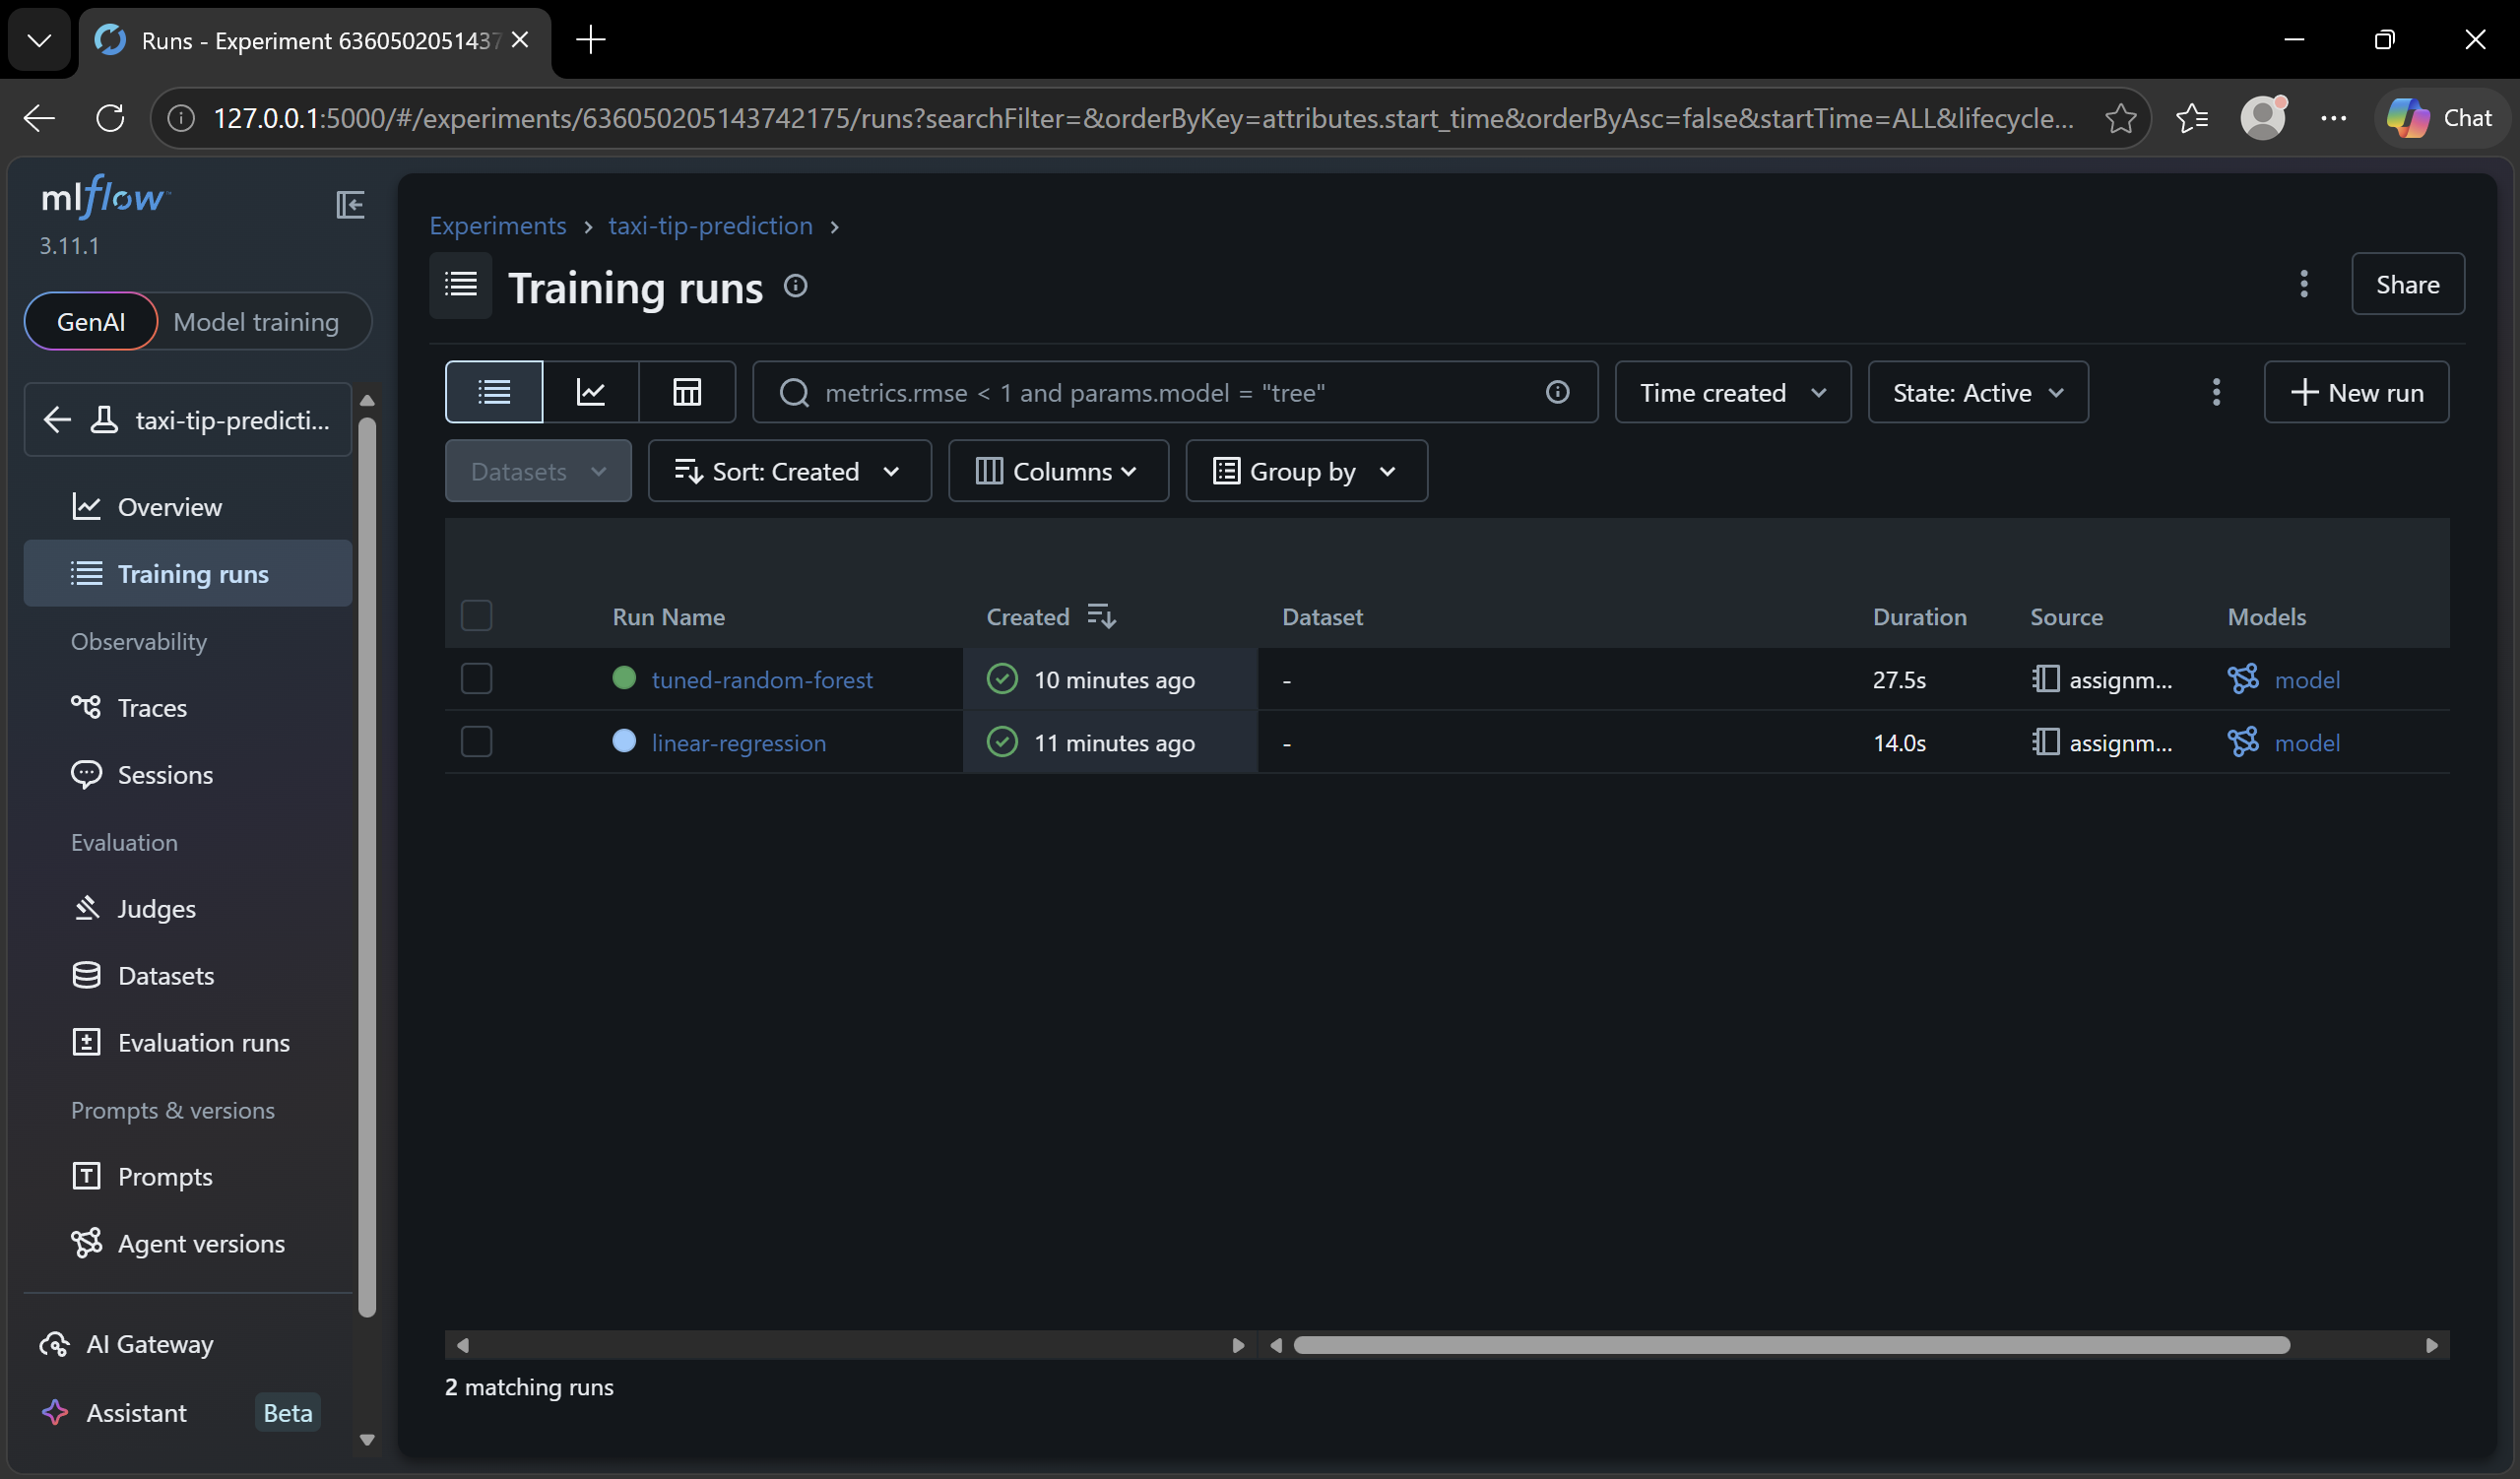
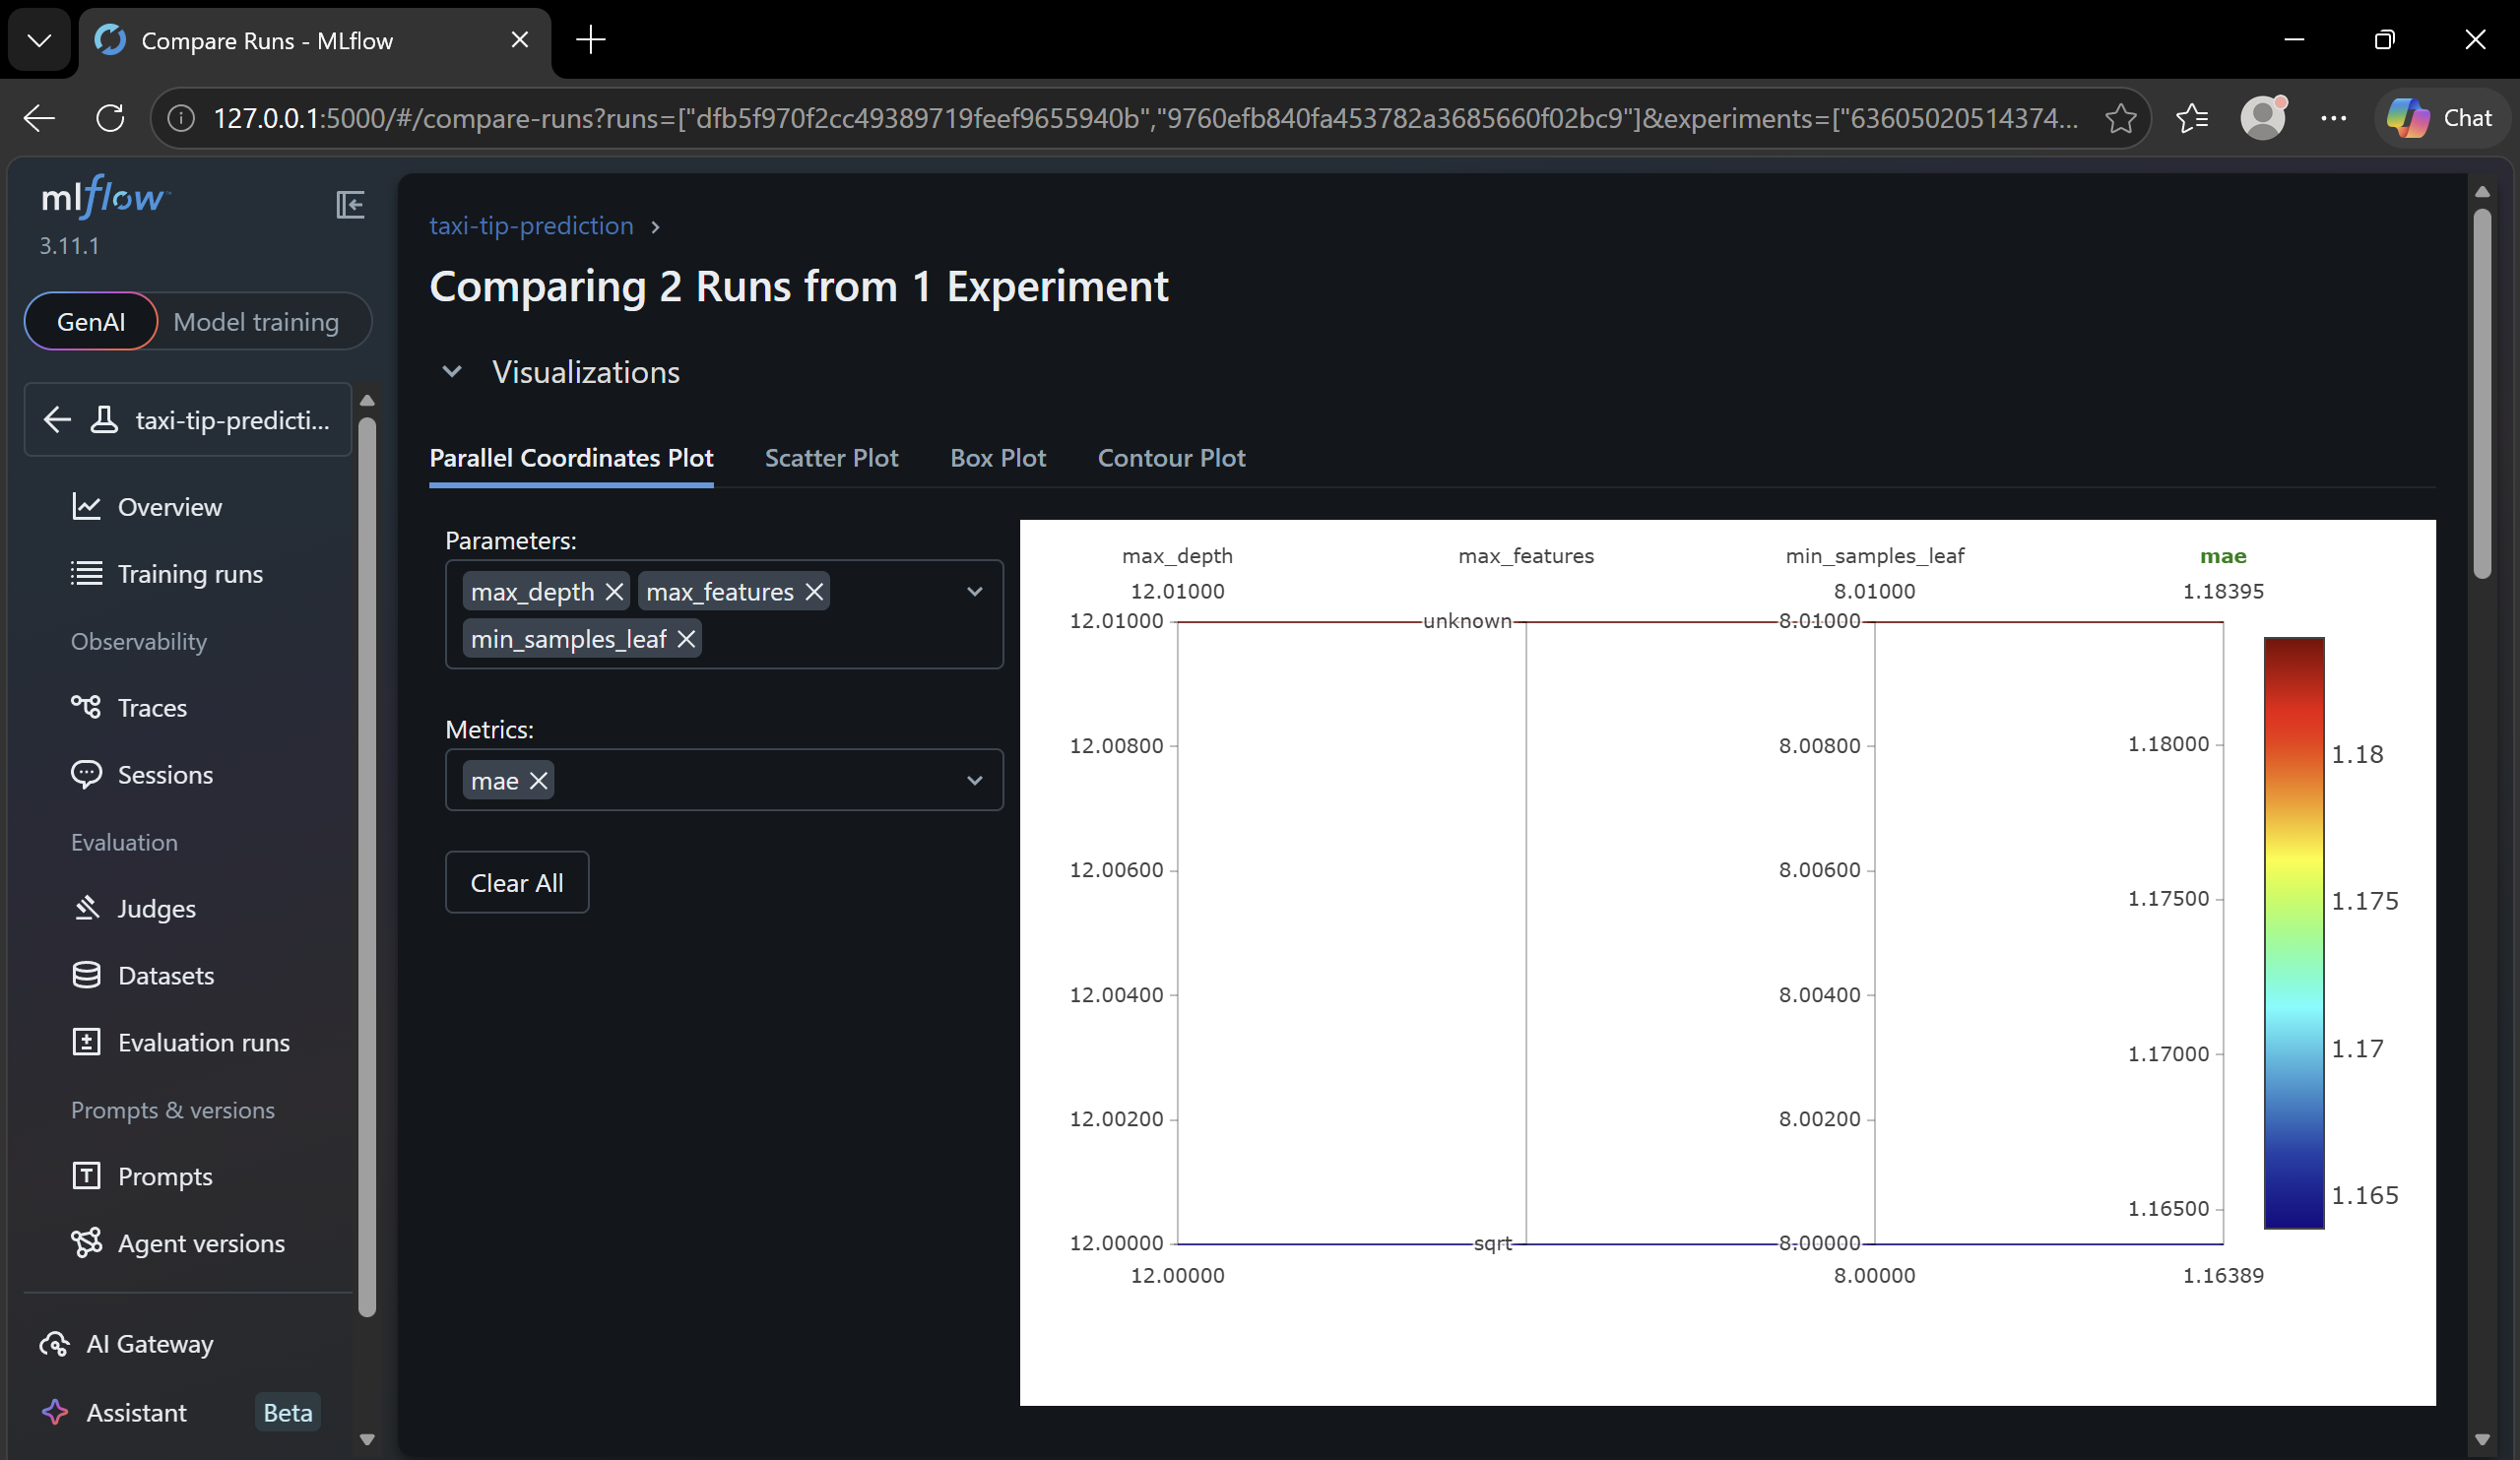

### Registering the best model

The Tuned Random Forest is registered in the MLflow Model Registry under the name `taxi-tip-regressor`.

In [38]:
from mlflow.tracking import MlflowClient

# Find the run ID for the tuned random forest
best_run = runs_latest.loc[runs_latest["metrics.r2"].idxmax()]
best_run_id = best_run["run_id"]
print(f"Best run ID: {best_run_id}")
print(f"Best R²: {best_run['metrics.r2']:.4f}")

# Register the model
model_uri = f"runs:/{best_run_id}/model"
result = mlflow.register_model(
    model_uri=model_uri,
    name="taxi-tip-regressor",
)
print(f"Registered model: {result.name}, version: {result.version}")

# Add description
client = MlflowClient()
client.update_model_version(
    name="taxi-tip-regressor",
    version=result.version,
    description=(
        f"Tuned RandomForestRegressor. "
        f"MAE={best_run['metrics.mae']:.4f}, "
        f"RMSE={best_run['metrics.rmse']:.4f}, "
        f"R²={best_run['metrics.r2']:.4f}. "
        f"Trained on NYC Yellow Taxi Jan 2024 data."
    ),
)

Registered model 'taxi-tip-regressor' already exists. Creating a new version of this model...
2026/04/13 18:16:07 WARNING mlflow.tracking._model_registry.fluent: Run with id fbeebce27a3841bd896d4be771965b91 has no artifacts at artifact path 'model', registering model based on models:/m-affe0712278e48e2b03ccb27979373bf instead


Best run ID: fbeebce27a3841bd896d4be771965b91
Best R²: 0.6292
Registered model: taxi-tip-regressor, version: 3


Created version '3' of model 'taxi-tip-regressor'.


<ModelVersion: aliases=[], creation_timestamp=1776118567577, current_stage='None', deployment_job_state=None, description=('Tuned RandomForestRegressor. MAE=1.1636, RMSE=2.2842, R²=0.6292. Trained on '
 'NYC Yellow Taxi Jan 2024 data.'), last_updated_timestamp=1776118567593, metrics=None, model_id=None, name='taxi-tip-regressor', params=None, run_id='fbeebce27a3841bd896d4be771965b91', run_link=None, source='models:/m-affe0712278e48e2b03ccb27979373bf', status='READY', status_message=None, tags={}, user_id=None, version=3, workspace='default'>

### Interpretation

The output shows that the model was successfully registered as version 3 of `taxi-tip-regressor`, since a previous version already existed. The selected run had the highest R² (0.6292), confirming it as the best-performing model, and the warning does not impact functionality.

### Loading from the registry

In [39]:
# Load from registry
loaded_model = mlflow.sklearn.load_model(f"models:/{result.name}/{result.version}")

# Sample prediction using one test row
sample = X_test.iloc[:1]
prediction = loaded_model.predict(sample)[0]
actual = y_test_reg.iloc[0]

print(f"Predicted tip: ${prediction:.2f}")
print(f"Actual tip:    ${actual:.2f}")

Predicted tip: $2.66
Actual tip:    $3.16


The predicted tip ($2.66) is close to the actual tip ($3.16), showing that the model produces reasonably accurate estimates despite minor error.

## Saving Model Artifacts for API Deployment

The trained model, feature column order, and zone lookup dictionary are saved using `joblib`. These artifacts are loaded by `app.py` at startup.

In [40]:
# Save the trained model
best_model = mlflow.sklearn.load_model(f"models:/{result.name}/{result.version}")
joblib.dump(best_model, "models/model.pkl")
print("Saved model to models/model.pkl")

# Save the training feature column order
joblib.dump(list(X_train.columns), "models/feature_columns.pkl")
print(f"Saved {len(X_train.columns)} feature columns to models/feature_columns.pkl")

# Zone lookup was already saved above
print("All model artifacts saved to models/")

Saved model to models/model.pkl
Saved 37 feature columns to models/feature_columns.pkl
All model artifacts saved to models/


### Summary

The Tuned Random Forest Regressor performed best, achieving the lowest MAE (1.1636), lowest RMSE (2.2842), and highest R² (0.6292) compared to the Linear Regression model. These metrics indicate more accurate predictions and better ability to capture patterns in the data. As a result, it was selected for registration and deployment using MLflow.

---

# Part 2: Model Serving with FastAPI

In this section, a REST API is built using FastAPI to serve predictions from the trained model. The API includes input validation with Pydantic, multiple endpoints, error handling, and automated tests using `pytest`.

### Task 2.1: API Design & Implementation 

The FastAPI application is defined in `app.py`. The model is loaded once at startup via a `lifespan` handler, and Pydantic validates all inputs with explicit constraints (e.g., `trip_distance > 0`, `pickup_hour` in 0–23, `fare_amount` ≤ 500). A `preprocess_input()` function transforms incoming data into the same feature schema used during training, including engineered features, borough encoding, and column alignment.

In [41]:
# Display app.py contents
with open("app.py", "r") as f:
    print(f.read())

"""
FastAPI application for NYC Taxi Tip Amount Prediction.
Serves predictions from a trained Random Forest model using the same
preprocessing pipeline as Assignment 2.
"""

from fastapi import FastAPI, Request
from fastapi.responses import JSONResponse
from pydantic import BaseModel, Field
from contextlib import asynccontextmanager
from typing import List
import joblib
import numpy as np
import pandas as pd
import uuid
import time
import os

# ---------------------------------------------------------------------------
# Global variables
# ---------------------------------------------------------------------------
ml_model = None
feature_columns = None
zone_lookup = None
start_time = None

MODEL_PATH = os.getenv("MODEL_PATH", "models/model.pkl")
FEATURE_COLUMNS_PATH = os.getenv("FEATURE_COLUMNS_PATH", "models/feature_columns.pkl")
ZONE_LOOKUP_PATH = os.getenv("ZONE_LOOKUP_PATH", "models/zone_lookup.pkl")
MODEL_VERSION = "1.0.0"


# ------------------------------------------------------

### Summary

The FastAPI application provides a reliable prediction service with validated inputs, consistent preprocessing, and efficient model loading at startup. The API returns structured outputs including the predicted tip amount, model version, and prediction ID, ensuring traceability and deployment readiness.

### Task 2.2: Enhanced API Features

The API was extended with additional endpoints to support batch predictions, system monitoring, and model transparency.

| Endpoint | Method | Description |
|---|---|---|
| `/predict` | POST | Single tip prediction |
| `/predict/batch` | POST | Batch predictions (max 100 records) |
| `/health` | GET | API status, model loaded, uptime |
| `/model/info` | GET | Model metadata and hyperparameters |

The `/predict/batch` endpoint enforces a maximum of 100 records per request and returns predictions along with processing time. The `/health` endpoint provides real-time information about API status and model availability, while the `/model/info` endpoint exposes key details such as feature names, hyperparameters, and evaluation metrics (MAE, RMSE, R²).

A global exception handler is implemented to catch unexpected errors and return structured JSON responses (HTTP 500) without exposing internal details, ensuring robustness and reliability.

### Task 2.3: API Testing

Automated tests are written in `test_app.py` using `pytest` and FastAPI’s `TestClient`. The test suite contains 11 test cases covering successful single and batch predictions, invalid input handling, the health check endpoint, model metadata, and edge cases such as very short trips and extreme fare values.

In [42]:
# Display test_app.py contents
with open("test_app.py", "r") as f:
    print(f.read())

"""
Test suite for the NYC Taxi Tip Predictor API.
Covers: valid predictions, batch predictions, invalid input,
health check, model info, and edge cases.
"""

from fastapi.testclient import TestClient
from app import app

client = TestClient(app)

# A valid sample trip matching the Assignment 2 feature schema
VALID_TRIP = {
    "trip_distance": 3.5,
    "fare_amount": 18.0,
    "pickup_hour": 14,
    "pickup_day_of_week": 2,
    "passenger_count": 1,
    "VendorID": 1,
    "RatecodeID": 1,
    "store_and_fwd_flag": 0,
    "PULocationID": 140,
    "DOLocationID": 236,
    "payment_type": 1,
    "extra": 1.0,
    "mta_tax": 0.5,
    "tolls_amount": 0.0,
    "improvement_surcharge": 1.0,
    "congestion_surcharge": 2.5,
    "Airport_fee": 0.0,
    "trip_duration_minutes": 15.0,
}


def test_root():
    """Root endpoint returns a welcome message."""
    response = client.get("/")
    assert response.status_code == 200
    assert "message" in response.json()


def test_health():
    """Heal

### Running the tests

In [44]:
!pip install pytest


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [50]:
import sys
!{sys.executable} -m pytest test_app.py -v

============================= test session starts =============================
platform win32 -- Python 3.11.9, pytest-7.0.1, pluggy-1.6.0 -- c:\Users\sonal\AppData\Local\Programs\Python\Python311\python.exe
cachedir: .pytest_cache
rootdir: c:\Users\sonal\COMP3610_A4
plugins: anyio-4.12.1
collecting ... collected 12 items

test_app.py::test_root PASSED                                            [  8%]
test_app.py::test_health PASSED                                          [ 16%]
test_app.py::test_predict_valid PASSED                                   [ 25%]
test_app.py::test_batch_prediction PASSED                                [ 33%]
test_app.py::test_model_info PASSED                                      [ 41%]
test_app.py::test_predict_missing_field PASSED                           [ 50%]
test_app.py::test_predict_invalid_type PASSED                            [ 58%]
test_app.py::test_predict_out_of_range_negative_distance PASSED          [ 66%]
test_app.py::test_predict_pickup_h

### Interpretation

All 12 tests passed successfully, confirming that the API correctly handles valid predictions, batch requests, invalid inputs, health checks, model metadata, and edge cases. This demonstrates that the deployed service is functioning reliably and that validation constraints are enforced as expected.

### Swagger UI Documentation

The screenshots below show the auto-generated Swagger UI documentation for the deployed API, including the available endpoints and an example prediction request/response.

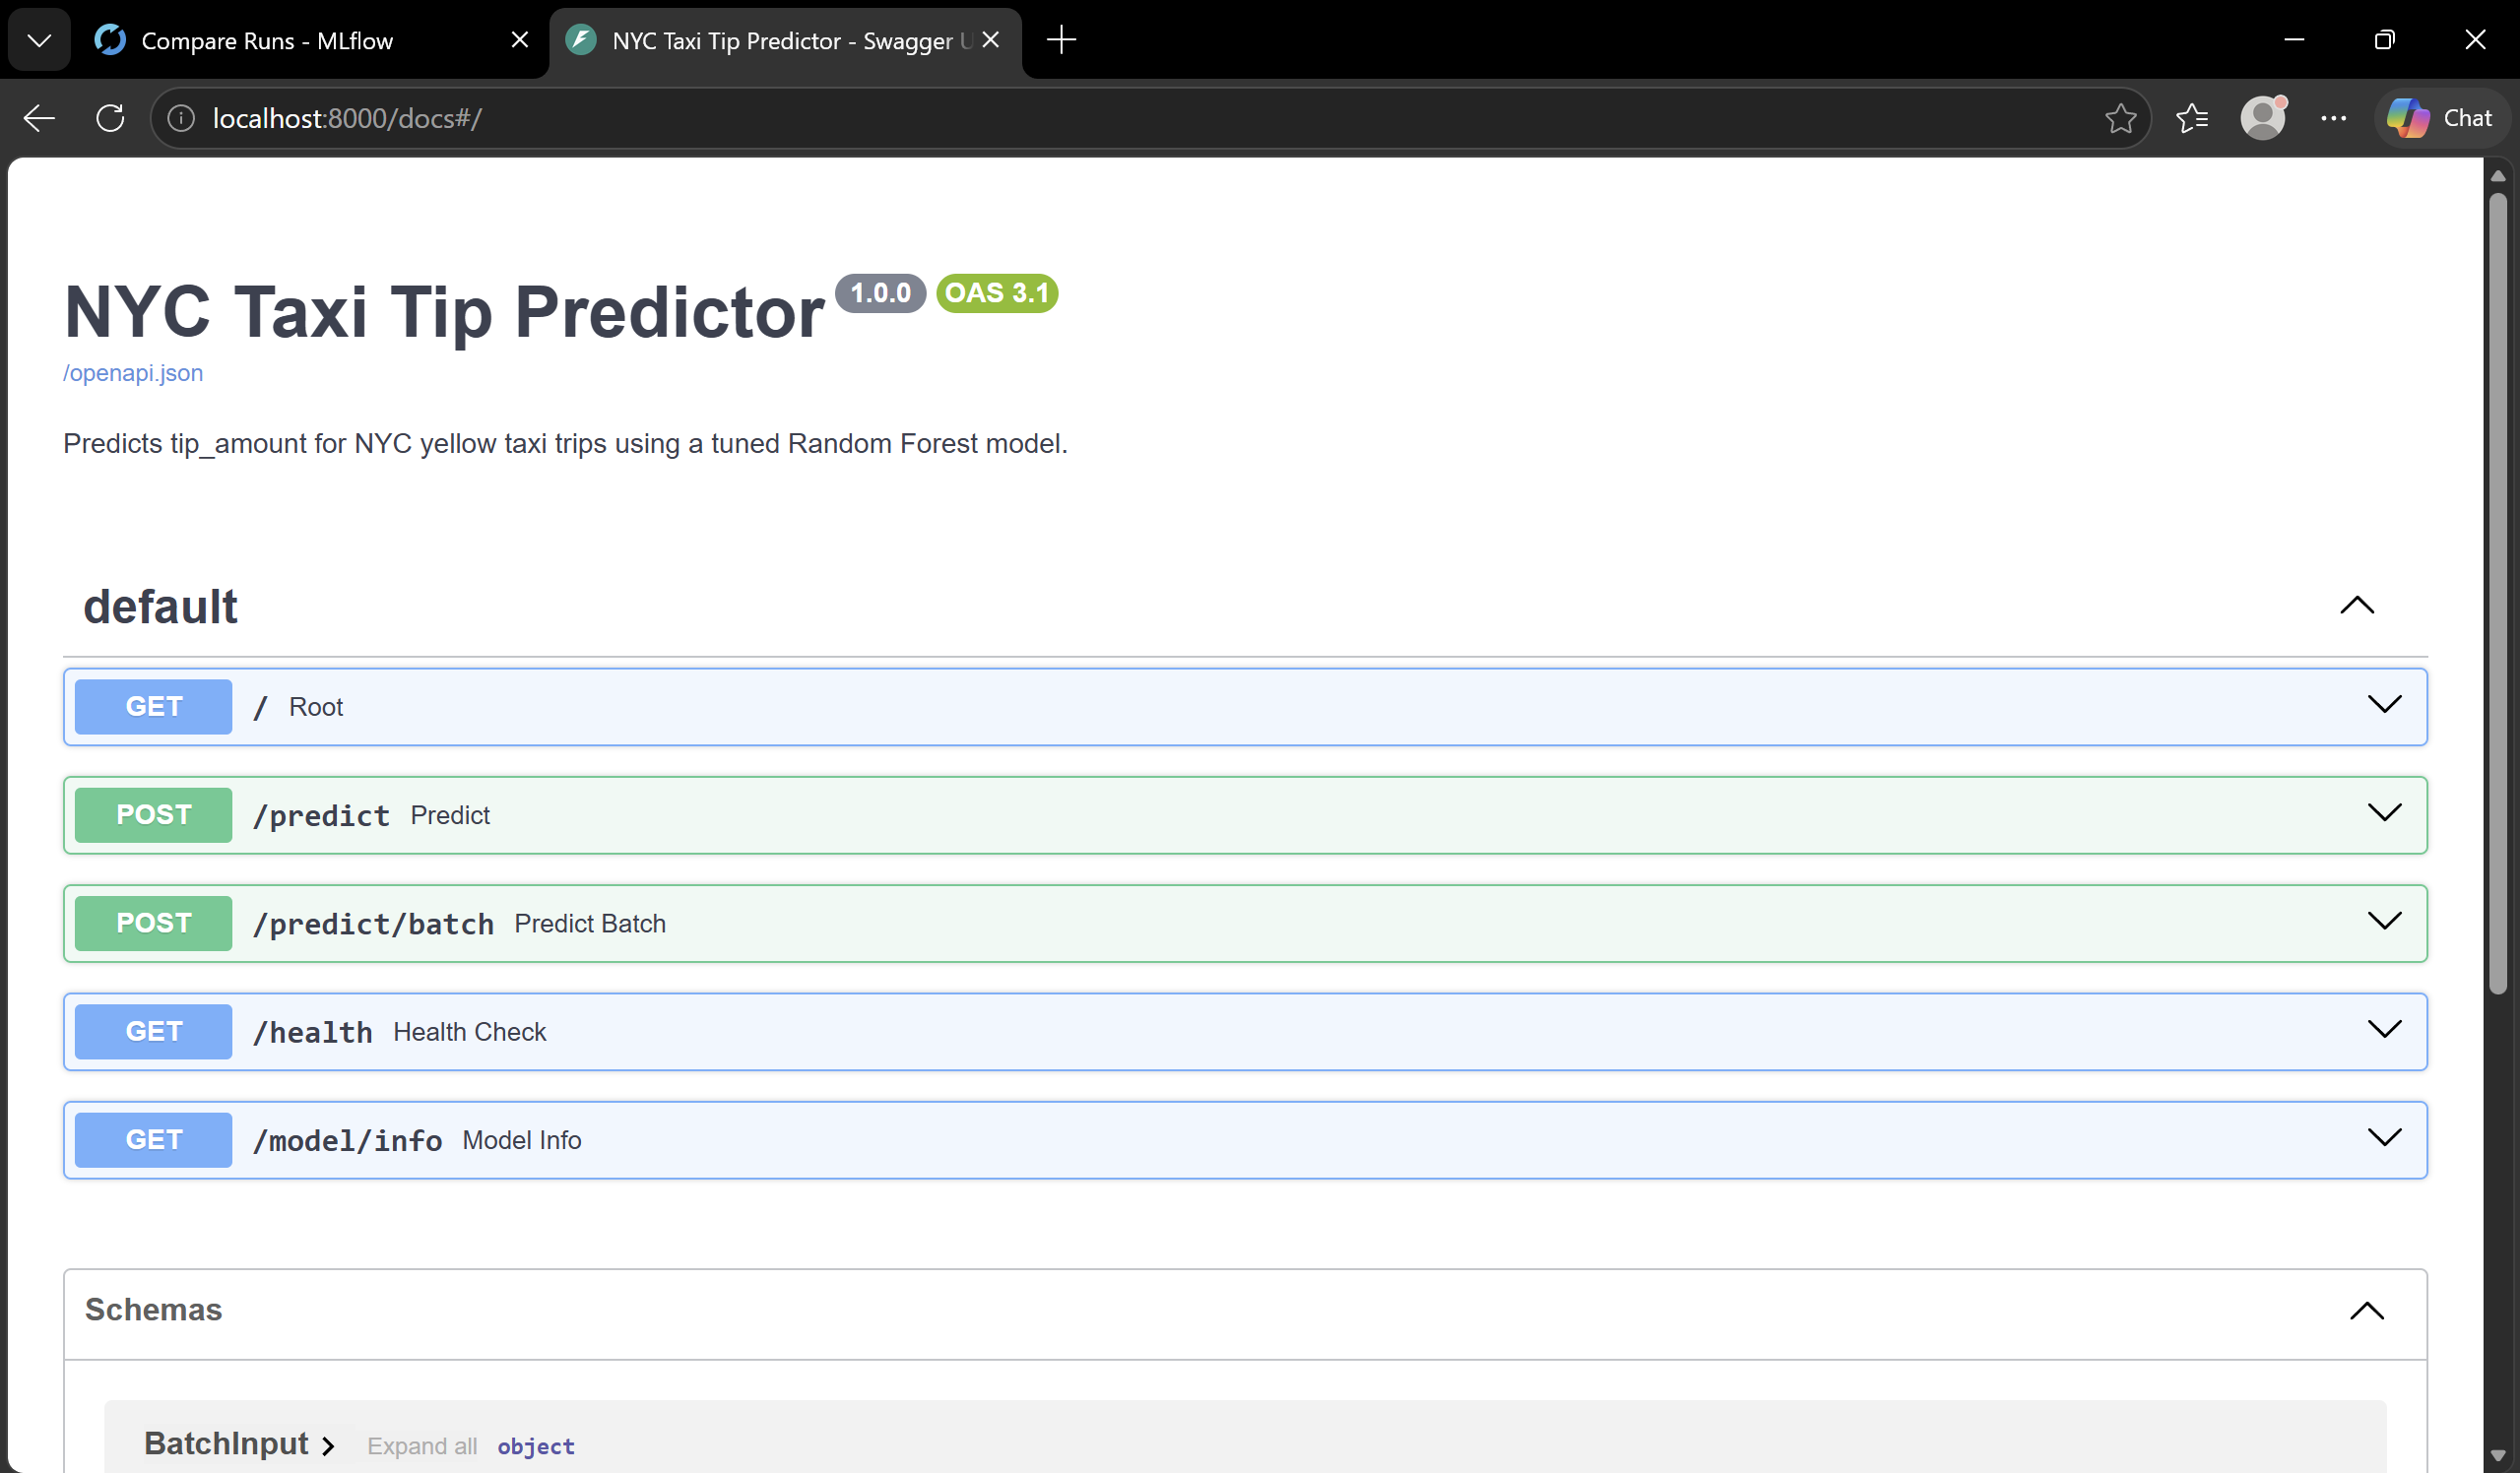
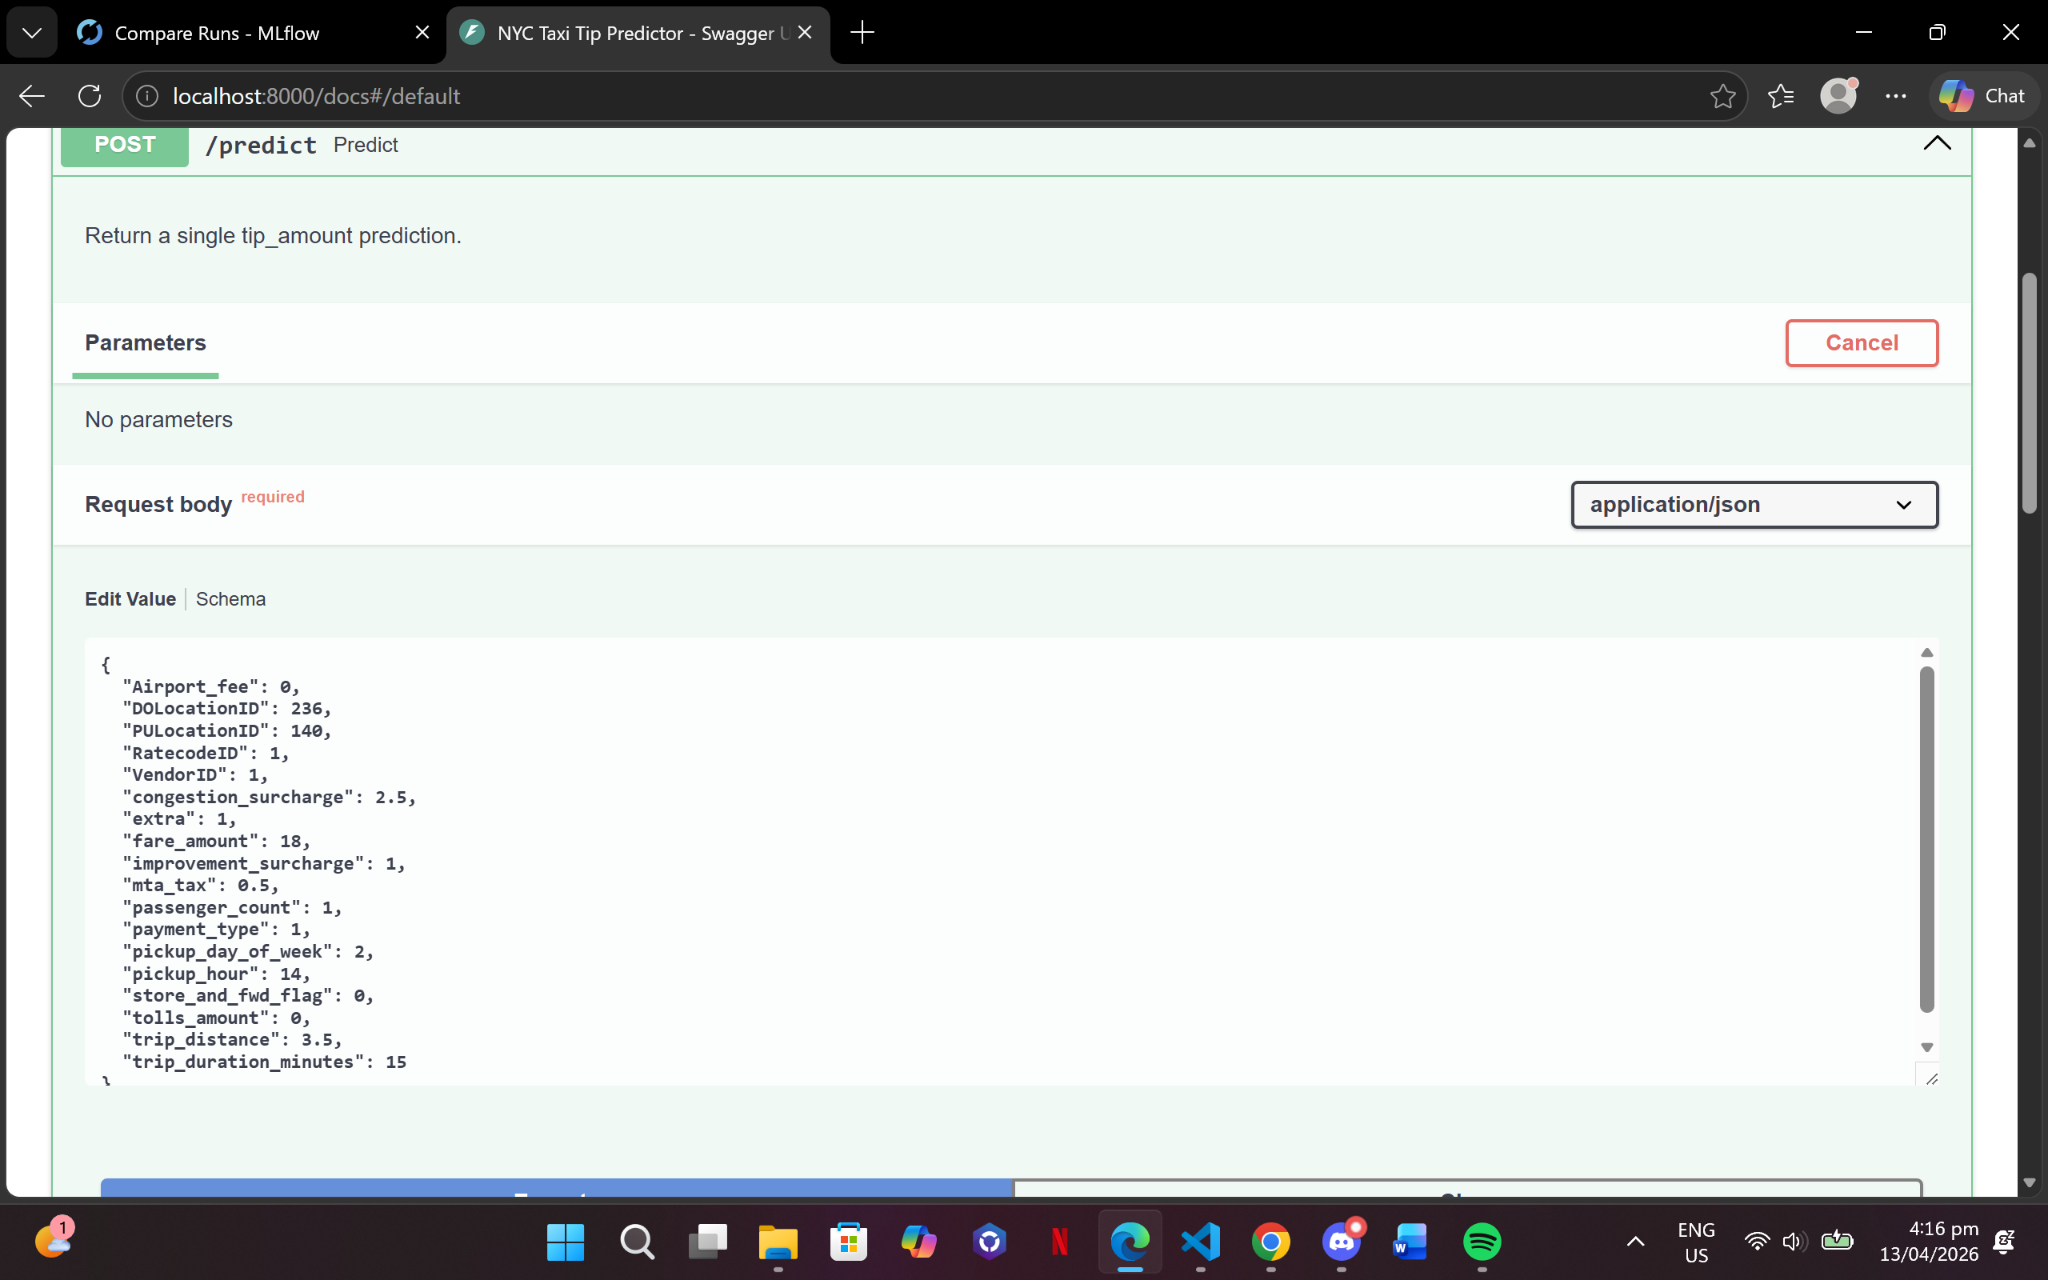
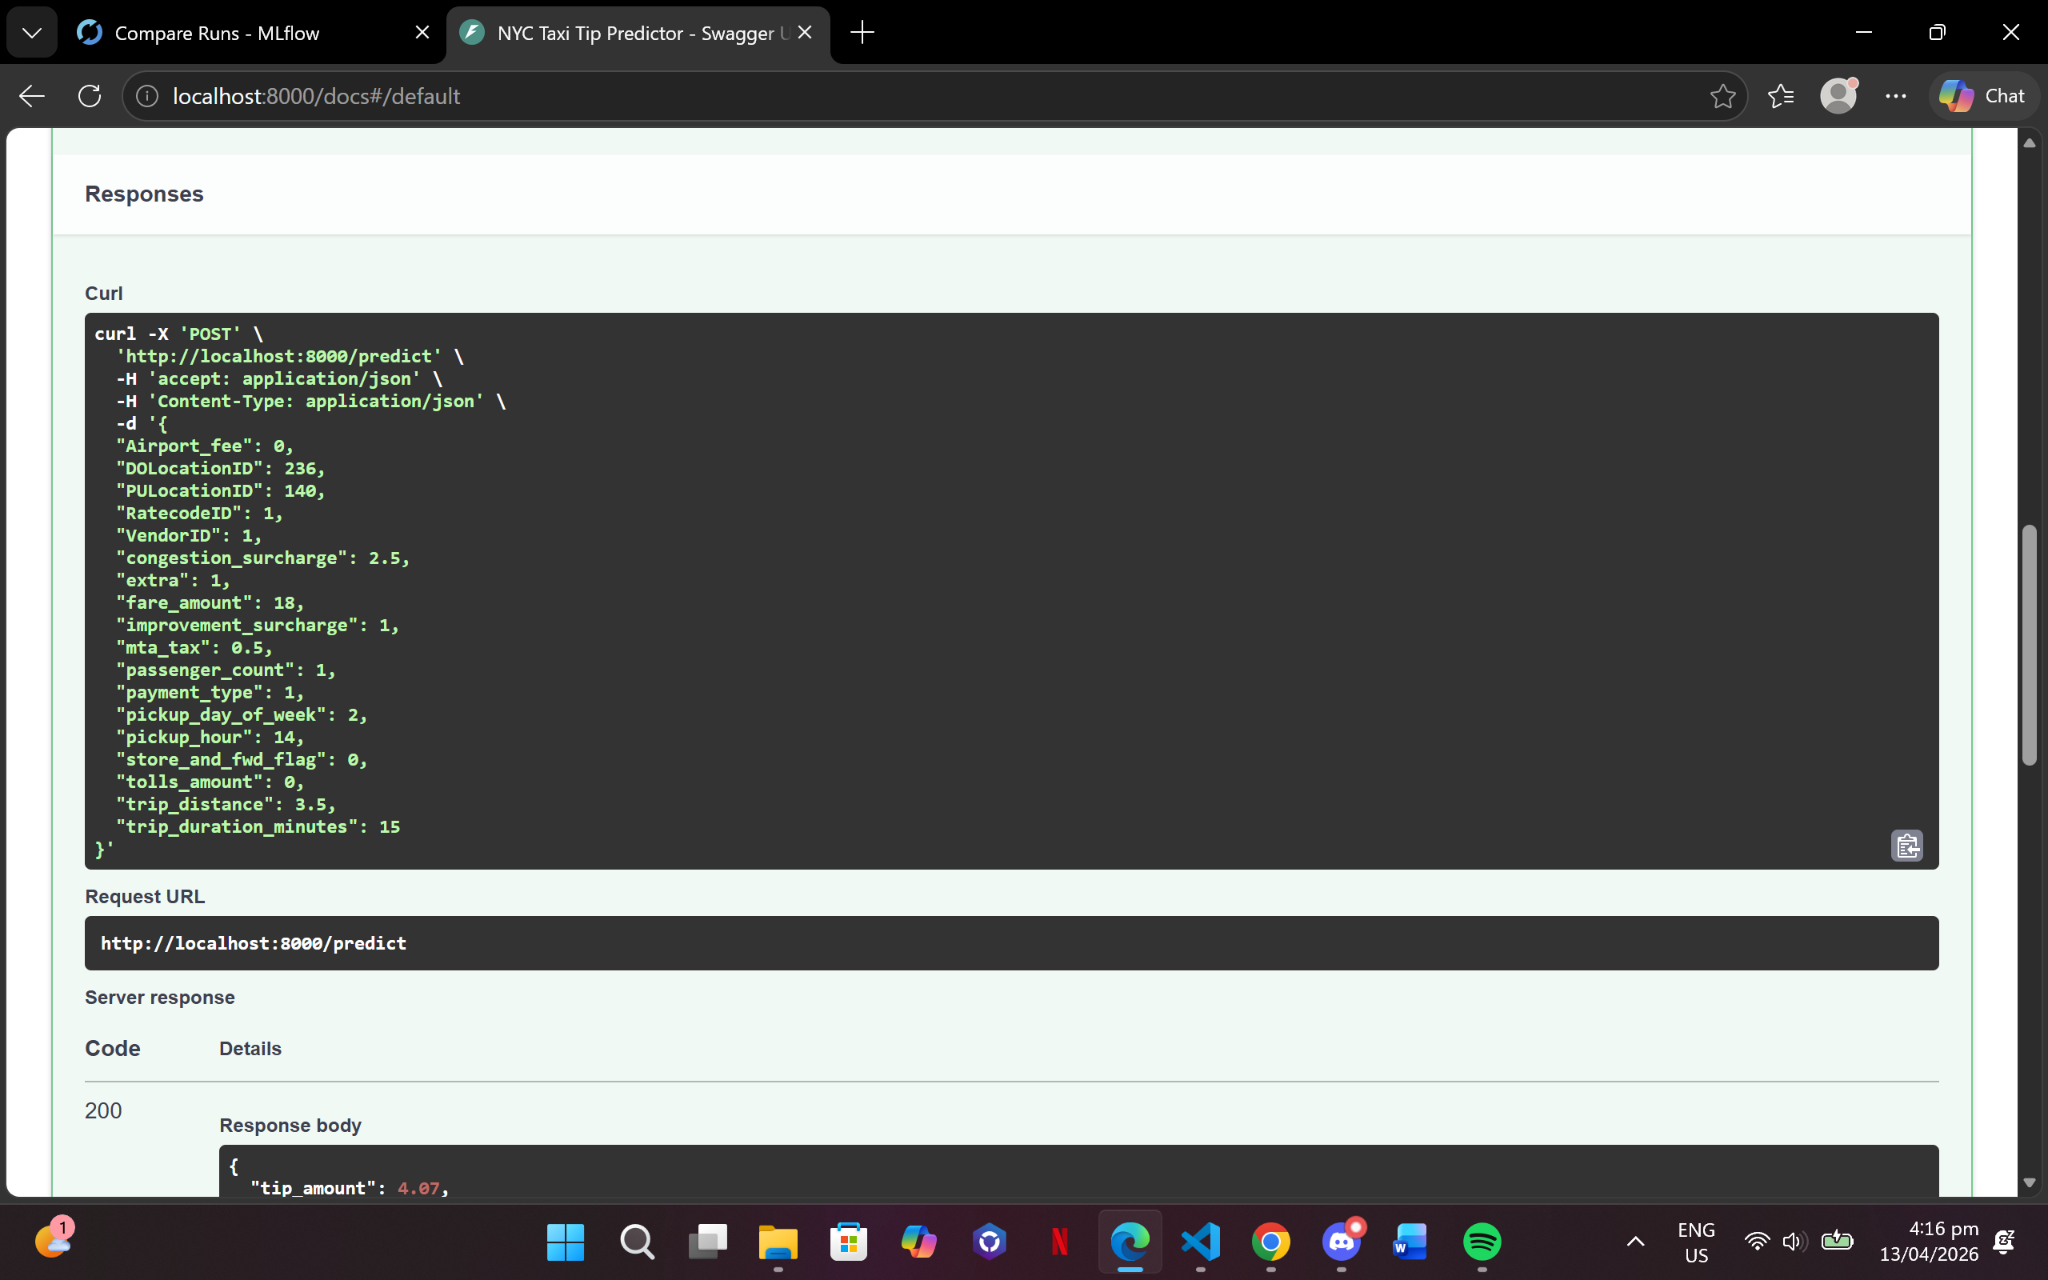

---

# Part 3: Containerization with Docker

In this section, the prediction service is containerized using Docker. A lightweight image is built for the FastAPI application, and the container is tested to confirm that the API is accessible and functional. Docker Compose is used later to orchestrate multiple services.

### Task 3.1: Dockerfile & Image Building

The `Dockerfile` uses `python:3.11-slim` as the base image. `requirements.txt` is copied and installed before application code for layer caching, and `--no-cache-dir` keeps the image lean. A `.dockerignore` excludes data files, notebooks, and git history from the build context.

In [51]:
# Display Dockerfile
print("=" * 60)
print("Dockerfile")
print("=" * 60)
with open("Dockerfile", "r") as f:
    print(f.read())

print("\n" + "=" * 60)
print(".dockerignore")
print("=" * 60)
with open(".dockerignore", "r") as f:
    print(f.read())

Dockerfile
# Base image - slim variant keeps the image small (~150 MB base)
FROM python:3.11-slim

# Set working directory inside the container
WORKDIR /app

# Copy dependency file first for Docker layer caching
COPY requirements.txt .

# Install Python dependencies without caching pip files
RUN pip install --no-cache-dir -r requirements.txt

# Copy application code and model artifacts
COPY app.py .
COPY models/ ./models/

# Document the port the app listens on
EXPOSE 8000

# Start the FastAPI server - bind to 0.0.0.0 so it is reachable from outside
CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]


.dockerignore
# Exclude unnecessary files from Docker build context
__pycache__/
*.pyc
.git/
.gitignore
data/
*.parquet
*.csv
mlruns/
mlartifacts/
.env
*.ipynb
*.md
.pytest_cache/
.ipynb_checkpoints/
venv/
.venv/



### Summary

The Dockerfile creates a lightweight container using `python:3.11-slim`, installs dependencies, and copies only the required application code and model files. It exposes port 8000 and runs the FastAPI app with Uvicorn, allowing external access. A `.dockerignore` file excludes unnecessary files to keep the image efficient.

In [52]:
!docker build -t taxi-tip-api .

#0 building with "desktop-linux" instance using docker driver

#1 [internal] load build definition from Dockerfile
#1 transferring dockerfile: 671B 0.0s done
#1 DONE 0.0s

#2 [internal] load metadata for docker.io/library/python:3.11-slim
#2 ...

#3 [auth] library/python:pull token for registry-1.docker.io
#3 DONE 0.0s

#2 [internal] load metadata for docker.io/library/python:3.11-slim
#2 DONE 1.2s

#4 [internal] load .dockerignore
#4 transferring context: 258B done
#4 DONE 0.0s

#5 [1/6] FROM docker.io/library/python:3.11-slim@sha256:233de06753d30d120b1a3ce359d8d3be8bda78524cd8f520c99883bfe33964cf
#5 resolve docker.io/library/python:3.11-slim@sha256:233de06753d30d120b1a3ce359d8d3be8bda78524cd8f520c99883bfe33964cf 0.0s done
#5 DONE 0.0s

#6 [internal] load build context
#6 transferring context: 6.37MB 0.3s done
#6 DONE 0.3s

#7 [2/6] WORKDIR /app
#7 CACHED

#8 [3/6] COPY requirements.txt .
#8 CACHED

#9 [4/6] RUN pip install --no-cache-dir -r requirements.txt
#9 CACHED

#10 [5/6] COPY 

### Summary 

The Docker image built successfully using the provided Dockerfile. The logs show that the base image was pulled, dependencies were installed, and the application files were copied into the image. The final image was created and tagged as `taxi-tip-api:latest`, confirming that the container is ready to be run.

In [53]:
# Report image size
!docker images taxi-tip-api

IMAGE                 ID             DISK USAGE   CONTENT SIZE   EXTRA
taxi-tip-api:latest   8b63a2ede54f       1.27GB          288MB        


The Docker image was built successfully with a total disk usage of approximately 1.27 GB. This size includes the base image, installed dependencies, and model artifacts required for the application. The image is tagged as `taxi-tip-api:latest` and is ready for deployment.

In [54]:
import time, subprocess, json

# Clean up any previous container
!docker rm -f taxi-api 2>nul

# Start the container
!docker run -d --name taxi-api -p 8000:8000 taxi-tip-api

# Wait for the server to be ready
print("Waiting for container to start...")
time.sleep(5)

# Health check
print("\n--- Health Check ---")
!curl -s http://localhost:8000/health

# Sample prediction
print("\n\n--- Sample Prediction ---")
!curl -s -X POST http://localhost:8000/predict -H "Content-Type: application/json" -d "{\"trip_distance\": 3.5, \"fare_amount\": 18.0, \"pickup_hour\": 14, \"pickup_day_of_week\": 2, \"passenger_count\": 1, \"VendorID\": 1, \"RatecodeID\": 1, \"PULocationID\": 140, \"DOLocationID\": 236, \"trip_duration_minutes\": 15.0}"

# Clean up
print("\n\n--- Stopping container ---")
!docker stop taxi-api
!docker rm taxi-api
print("Container removed.")

1cf60ca6ae73d3cbbabedc06b9e1f643cf5d4b0f286b7ecf61788a0e05dcc1dc
Waiting for container to start...

--- Health Check ---
{"status":"healthy","model_loaded":true,"model_version":"1.0.0","uptime_seconds":1.5}


--- Sample Prediction ---
{"tip_amount":3.99,"prediction_id":"b677e5d6-2edf-4164-800e-e9266a193d5e","model_version":"1.0.0"}


--- Stopping container ---
taxi-api
taxi-api
Container removed.


The Docker container started successfully and exposed the API on port 8000. The health check confirmed that the model was loaded and the service was running correctly. A sample prediction request returned a valid tip amount, demonstrating that the containerized API is functioning and accessible from outside the container.

### Task 3.2: Docker Compose & Deployment Demo

The `docker-compose.yml` file orchestrates two services: the FastAPI prediction API (port 8000) and an MLflow tracking server (port 5000). The API service builds from the local Dockerfile, maps port 8000, and uses environment variables to locate the trained model artifacts. A healthcheck is included for the API service, and `depends_on` ensures that the MLflow service starts before the API container. The API container image used in this deployment had a reported size of approximately 1.27 GB.

The main configuration required to run the project is Docker Desktop and the model artifact files stored in the `models/` directory. Environment variables in `docker-compose.yml` provide the paths for the model, feature columns, and zone lookup artifacts, and the MLflow service can be reached within the Docker network using the service name `mlflow`.

In [23]:
# Display docker-compose.yml
with open("docker-compose.yml", "r") as f:
    print(f.read())

services:
  # FastAPI prediction service
  api:
    build: .
    ports:
      - "8000:8000"
    environment:
      - MODEL_PATH=/app/models/model.pkl
      - FEATURE_COLUMNS_PATH=/app/models/feature_columns.pkl
      - ZONE_LOOKUP_PATH=/app/models/zone_lookup.pkl
    depends_on:
      - mlflow
    healthcheck:
      test: ["CMD", "curl", "-f", "http://localhost:8000/health"]
      interval: 30s
      timeout: 10s
      retries: 3

  # MLflow tracking server (bonus)
  mlflow:
    image: ghcr.io/mlflow/mlflow:v2.12.1
    ports:
      - "5000:5000"
    command: mlflow server --host 0.0.0.0 --port 5000
    volumes:
      - mlflow-data:/mlflow

volumes:
  mlflow-data:



### Deploying and testing with Docker Compose

In [24]:
import time

# 1. Build and start services
print("=" * 60)
print("Starting Docker Compose services...")
print("=" * 60)
!docker compose up -d --build

# 2. Wait for API to be ready
print("\nWaiting for API to start...")
time.sleep(10)

# 3. Show running containers
print("\n" + "=" * 60)
print("Running containers:")
print("=" * 60)
!docker compose ps

# 4. Health check
print("\n" + "=" * 60)
print("Health Check:")
print("=" * 60)
!curl -s http://localhost:8000/health

# 5. Prediction requests
print("\n\n" + "=" * 60)
print("Prediction 1 — Standard trip (Midtown to Upper East Side)")
print("=" * 60)
!curl -s -X POST http://localhost:8000/predict -H "Content-Type: application/json" -d "{\"trip_distance\": 3.5, \"fare_amount\": 18.0, \"pickup_hour\": 14, \"pickup_day_of_week\": 2, \"passenger_count\": 1, \"VendorID\": 1, \"RatecodeID\": 1, \"PULocationID\": 140, \"DOLocationID\": 236, \"trip_duration_minutes\": 15.0}"

print("\n\n" + "=" * 60)
print("Prediction 2 — Airport trip (JFK)")
print("=" * 60)
!curl -s -X POST http://localhost:8000/predict -H "Content-Type: application/json" -d "{\"trip_distance\": 18.0, \"fare_amount\": 70.0, \"pickup_hour\": 8, \"pickup_day_of_week\": 4, \"passenger_count\": 2, \"VendorID\": 2, \"RatecodeID\": 2, \"PULocationID\": 132, \"DOLocationID\": 1, \"trip_duration_minutes\": 45.0, \"Airport_fee\": 1.75}"

print("\n\n" + "=" * 60)
print("Prediction 3 — Short weekend trip")
print("=" * 60)
!curl -s -X POST http://localhost:8000/predict -H "Content-Type: application/json" -d "{\"trip_distance\": 0.8, \"fare_amount\": 7.0, \"pickup_hour\": 22, \"pickup_day_of_week\": 5, \"passenger_count\": 1, \"VendorID\": 1, \"RatecodeID\": 1, \"PULocationID\": 236, \"DOLocationID\": 140, \"trip_duration_minutes\": 5.0}"

# 6. Tear down
print("\n\n" + "=" * 60)
print("Stopping and removing containers...")
print("=" * 60)
!docker compose down
print("Done.")

Starting Docker Compose services...


 Image ghcr.io/mlflow/mlflow:v2.12.1 Pulling 
 a2f7bd89bd91 Pulling fs layer 0B
 1a17b335a5a9 Pulling fs layer 0B
 97413375e23b Pulling fs layer 0B
 50b8e058ed51 Pulling fs layer 0B
 f39cc05dd63a Pulling fs layer 0B
 04e7578caeaa Pulling fs layer 0B
 f533bbc951bf Download complete 0B
 50b8e058ed51 Download complete 0B
 a2f7bd89bd91 Downloading 1.049MB
 a2f7bd89bd91 Downloading 2.097MB
 1a17b335a5a9 Downloading 1.049MB
 1a17b335a5a9 Downloading 1.049MB
 a2f7bd89bd91 Downloading 4.194MB
 1a17b335a5a9 Downloading 2.097MB
 97413375e23b Download complete 0B
 a2f7bd89bd91 Downloading 6.291MB
 a2f7bd89bd91 Downloading 8.389MB
 1a17b335a5a9 Downloading 3.146MB
 f39cc05dd63a Downloading 1.049MB
 a2f7bd89bd91 Downloading 9.437MB
 1a17b335a5a9 Downloading 4.194MB
 f39cc05dd63a Downloading 1.049MB
 a2f7bd89bd91 Downloading 11.53MB
 1a17b335a5a9 Downloading 5.243MB
 a2f7bd89bd91 Downloading 12.58MB
 1a17b335a5a9 Downloading 5.243MB
 f39cc05dd63a Downloading 1.049MB
 04e7578caeaa Downloading 1.049MB

#1 [internal] load local bake definitions
#1 reading from stdin 507B done
#1 DONE 0.0s

#2 [internal] load build definition from Dockerfile
#2 transferring dockerfile: 675B done
#2 DONE 0.0s

#3 [internal] load metadata for docker.io/library/python:3.11-slim
#3 DONE 0.4s

#4 [internal] load .dockerignore
#4 transferring context: 258B done
#4 DONE 0.0s

#5 [internal] load build context
#5 transferring context: 216B done
#5 DONE 0.0s

#6 [1/6] FROM docker.io/library/python:3.11-slim@sha256:233de06753d30d120b1a3ce359d8d3be8bda78524cd8f520c99883bfe33964cf
#6 resolve docker.io/library/python:3.11-slim@sha256:233de06753d30d120b1a3ce359d8d3be8bda78524cd8f520c99883bfe33964cf 0.0s done
#6 DONE 0.0s

#7 [3/6] COPY requirements.txt .
#7 CACHED

#8 [5/6] COPY app.py .
#8 CACHED

#9 [2/6] WORKDIR /app
#9 CACHED

#10 [4/6] RUN pip install --no-cache-dir -r requirements.txt
#10 CACHED

#11 [6/6] COPY models/ ./models/
#11 CACHED

#12 exporting to image
#12 exporting layers done
#12 exporting manifest

 Container comp3610_a4-api-1 Stopping 
 Container comp3610_a4-api-1 Stopped 
 Container comp3610_a4-api-1 Removing 
 Container comp3610_a4-api-1 Removed 
 Container comp3610_a4-mlflow-1 Stopping 
 Container comp3610_a4-mlflow-1 Stopped 
 Container comp3610_a4-mlflow-1 Removing 
 Container comp3610_a4-mlflow-1 Removed 
 Network comp3610_a4_default Removing 
 Network comp3610_a4_default Removed 


### Docker Compose output

The screenshots below show Docker Compose running both services successfully. The `docker compose ps` output confirms both the `api` and `mlflow` containers are up. The health check returns a healthy status with the model loaded, and three prediction requests return reasonable tip amounts: $4.04 for a standard Midtown trip, $13.74 for a JFK airport trip, and $2.09 for a short weekend trip.

![Screenshot 2026-04-13 164901.png](<attachment:Screenshot 2026-04-13 164901.png>)
![Screenshot 2026-04-13 164922.png](<attachment:Screenshot 2026-04-13 164922.png>)
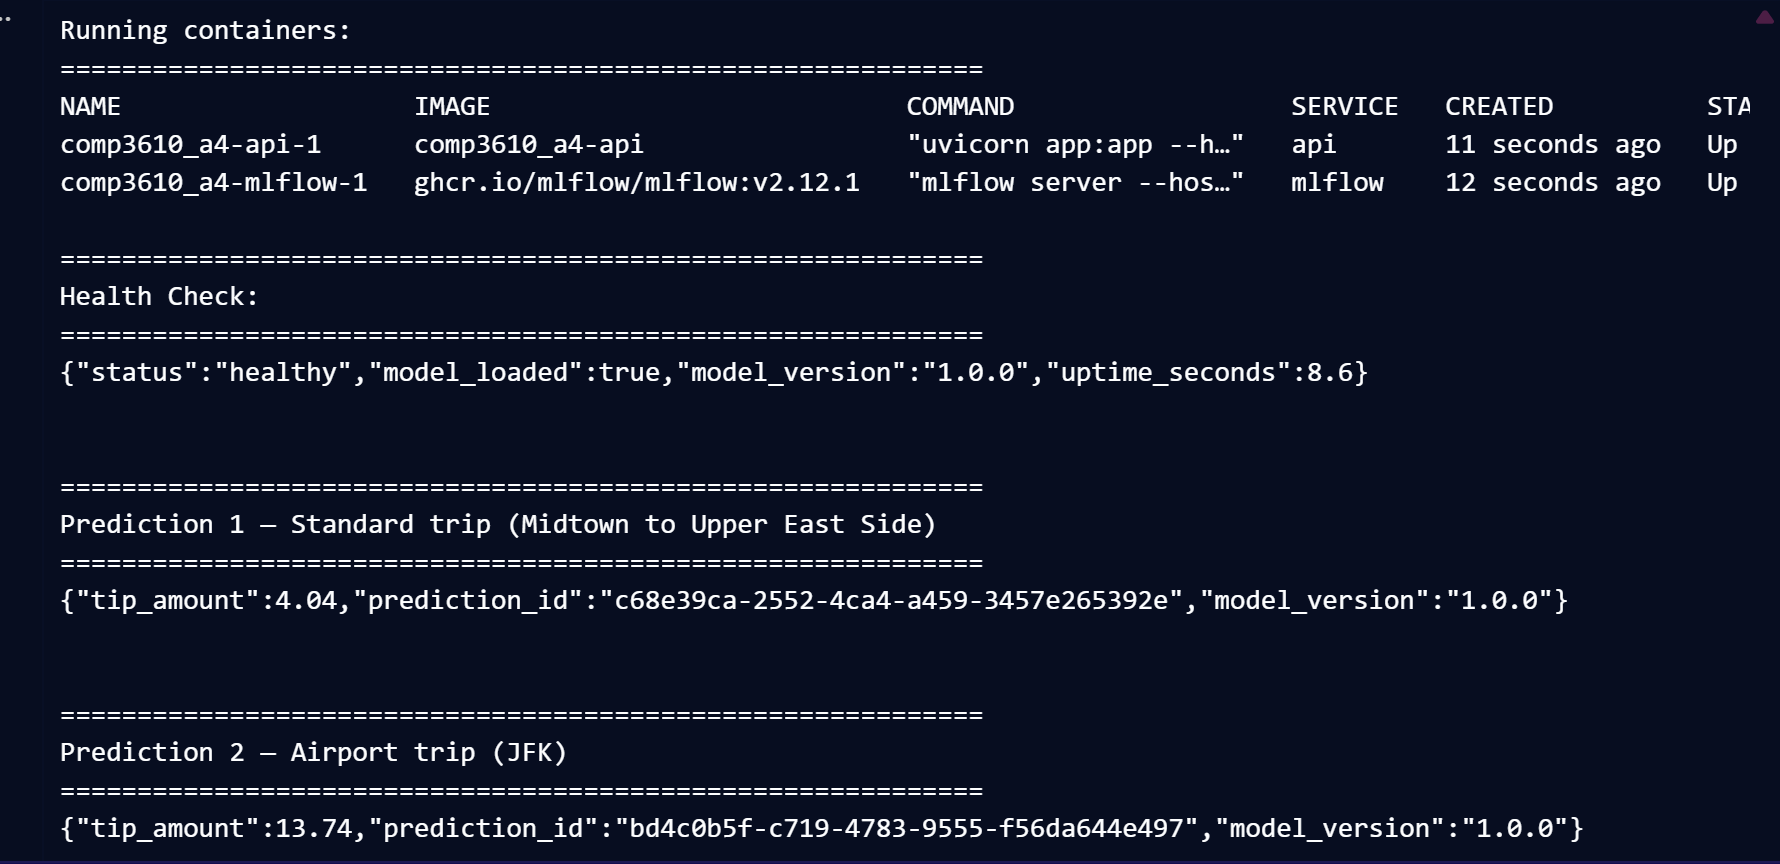
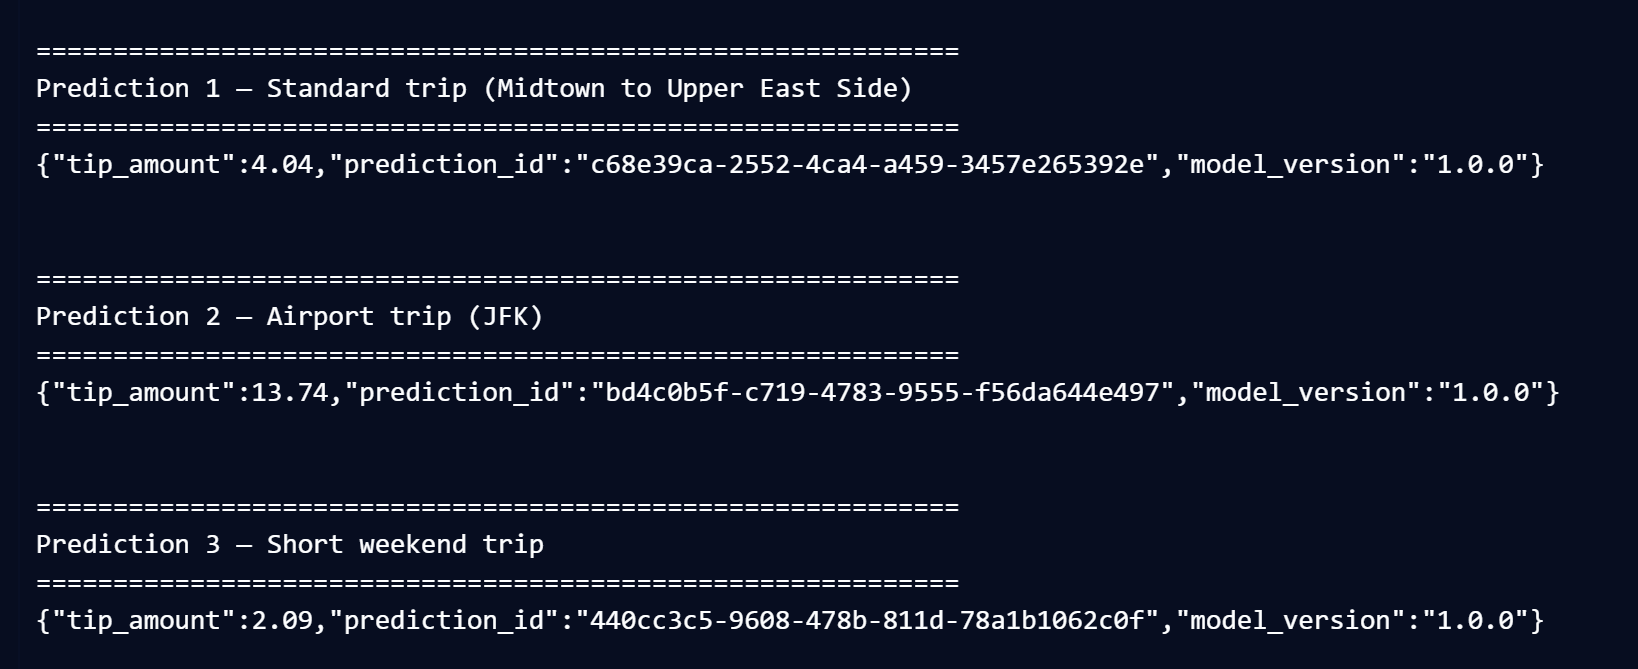

In [ ]:
# Display requirements.txt
print("=== requirements.txt ===")
with open("requirements.txt", "r") as f:
    print(f.read())

### Summary 

The deployment using Docker Compose was successful, with both the API and MLflow services running correctly in a coordinated environment. The API responded to multiple prediction requests with valid outputs, confirming that the containerized system is fully functional. This setup demonstrates a scalable and reproducible deployment workflow using container orchestration.

# AI Tools Used

AI assistance (ChatGPT) was used in the following ways during this assignment:

- Helping clarify assignment instructions and requirements.
- Providing general guidance on implementing the FastAPI application, Docker setup, and deployment workflow.
- Assisting with adapting the Assignment 2 preprocessing pipeline for use in the API inference path.
- Debugging issues related to feature alignment between training and inference, as well as API and testing errors.
- Supporting the creation and validation of the `test_app.py` test suite using FastAPI testing patterns.
- Suggesting improvements to notebook structure, documentation, and explanations.
- Assisting in generating supporting files such as the README, `.gitignore`, and `requirements.txt`.
